# Chapter 10.8: ByteDance, Alibaba & Others

## Learning Objectives

By the end of this notebook, you will be able to:

1. Understand ByteDance's **Monolith** system for real-time training + serving co-design
2. Analyze Alibaba's production pipeline: **COLD, SIM, TDM**, and the **PAI** platform
3. Describe Kuaishou's approach to **real-time short video recommendation**
4. Understand Pinterest's **PinSage, PinnerFormer**, and Homefeed ranking
5. Analyze LinkedIn's **GLMix** and feed ranking system
6. Describe Spotify's music and podcast recommendation architecture
7. Identify **common patterns** across all companies' recommendation stacks

## Prerequisites

- Chapter 10.6 (Meta's stack) and 10.7 (Tencent's stack)
- Understanding of recommendation model architectures
- Familiarity with distributed systems concepts

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hideak1/rec_system/blob/main/notebooks/part10/chapter_10.8_other_stacks.ipynb)
[![Download](https://img.shields.io/badge/Download-Notebook-blue)](https://raw.githubusercontent.com/hideak1/rec_system/main/notebooks/part10/chapter_10.8_other_stacks.ipynb)

In [1]:
import numpy as np
import time
from typing import List, Dict, Tuple, Optional
from dataclasses import dataclass, field
from collections import defaultdict, OrderedDict
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

np.random.seed(42)

print("All imports successful!")

All imports successful!


## 1. ByteDance Monolith: Real-Time Training + Serving

**Monolith** (Zhao et al., ICLR 2022) is ByteDance's production recommendation system. Its key innovation is **eliminating the gap between training and serving**:

Traditional approach:
$$
\text{Batch Training (hourly/daily)} \rightarrow \text{Model Export} \rightarrow \text{Serving}
$$

Monolith approach:
$$
\text{Real-time Training (seconds)} \leftrightarrow \text{Serving (same system)}
$$

Key innovations:

1. **Collisionless embedding table**: Unlike hash-based embeddings (used by Meta), Monolith uses a cuckoo hash table that avoids embedding collisions, improving recall
2. **Online training**: The serving model is continuously updated from the streaming data pipeline
3. **Feature eviction**: Old, unused embeddings are garbage-collected to manage memory
4. **Training-serving co-location**: Training and serving run on the same machines, sharing embeddings in memory

| Aspect | Traditional (Meta-style) | Monolith (ByteDance) |
|--------|------------------------|---------------------|
| Model freshness | Hours | Seconds |
| Feature freshness | Minutes (NRT) | Seconds |
| Embedding collisions | Yes (hash-based) | No (cuckoo hash) |
| Training-serving gap | High | Near zero |

> **💡 Concept:** The key insight behind Monolith is that in short-video recommendation (TikTok/Douyin), user interests change very quickly. A model trained on yesterday's data might already be stale for today's trending topics. Real-time training ensures the model always reflects the latest user behavior.

In [2]:
# Simulate ByteDance Monolith's real-time training

class CuckooHashEmbedding:
    """Collisionless embedding table using cuckoo hashing.

    Reference: Zhao et al., 'Monolith: Real Time Recommendation System
    With Collisionless Embedding Table' (2022, ByteDance, ICLR)
    """

    def __init__(self, capacity: int, embedding_dim: int, eviction_threshold: int = 100):
        self.capacity = capacity
        self.embedding_dim = embedding_dim
        self.eviction_threshold = eviction_threshold

        # Two hash tables for cuckoo hashing
        self.table1: Dict[int, np.ndarray] = {}
        self.table2: Dict[int, np.ndarray] = {}
        self.access_counts: Dict[int, int] = defaultdict(int)
        self.last_access: Dict[int, float] = {}
        self.collisions = 0
        self.total_lookups = 0

    def _hash1(self, key: int) -> int:
        return key % self.capacity

    def _hash2(self, key: int) -> int:
        return (key * 2654435761) % self.capacity  # Fibonacci hashing

    def lookup(self, key: int, current_time: float) -> np.ndarray:
        """Collisionless lookup."""
        self.total_lookups += 1
        self.access_counts[key] += 1
        self.last_access[key] = current_time

        h1 = self._hash1(key)
        if key in self.table1:
            return self.table1[key]

        h2 = self._hash2(key)
        if key in self.table2:
            return self.table2[key]

        # New key - create embedding
        emb = np.random.randn(self.embedding_dim).astype(np.float32) * 0.01
        self.table1[key] = emb
        return emb

    def update(self, key: int, gradient: np.ndarray, lr: float = 0.001):
        """Update embedding in-place."""
        if key in self.table1:
            self.table1[key] -= lr * gradient
        elif key in self.table2:
            self.table2[key] -= lr * gradient

    def evict(self, current_time: float, age_threshold: float = 3600.0):
        """Evict old, rarely-used embeddings."""
        evicted = 0
        keys_to_evict = []
        for key, last_time in self.last_access.items():
            if (current_time - last_time > age_threshold and
                    self.access_counts[key] < self.eviction_threshold):
                keys_to_evict.append(key)

        for key in keys_to_evict:
            self.table1.pop(key, None)
            self.table2.pop(key, None)
            del self.access_counts[key]
            del self.last_access[key]
            evicted += 1

        return evicted

    @property
    def size(self) -> int:
        return len(self.table1) + len(self.table2)


class MonolithSystem:
    """Simplified Monolith: real-time training + serving."""

    def __init__(self, num_features: int, embedding_dim: int):
        self.embedding = CuckooHashEmbedding(1000000, embedding_dim)
        self.model_version = 0
        self.serving_quality = 0.70  # Initial AUC
        self.quality_history = []
        self.freshness_history = []

    def serve_and_train(self, user_id: int, item_id: int,
                        label: int, current_time: float) -> Dict:
        """Combined serve + train step (Monolith's key innovation)."""
        # Serve: look up embeddings
        user_emb = self.embedding.lookup(user_id, current_time)
        item_emb = self.embedding.lookup(item_id + 1000000, current_time)

        # Score
        score = float(np.dot(user_emb, item_emb))
        pred = 1.0 / (1.0 + np.exp(-score))

        # Train: compute gradient and update in-place
        error = pred - label
        user_grad = error * item_emb
        item_grad = error * user_emb

        self.embedding.update(user_id, user_grad, lr=0.01)
        self.embedding.update(item_id + 1000000, item_grad, lr=0.01)

        self.model_version += 1

        return {"score": pred, "label": label, "version": self.model_version}


# Simulate real-time training vs batch training
np.random.seed(42)
monolith = MonolithSystem(num_features=10, embedding_dim=32)

# Generate a stream of interactions with concept drift
n_events = 10000
current_time = 0.0
batch_results = []
rt_results = []

# Simulate: trending topic changes at t=3000 and t=7000
trending_items_phase1 = list(range(100))    # First trend
trending_items_phase2 = list(range(100, 200))  # Second trend
trending_items_phase3 = list(range(200, 300))  # Third trend

for i in range(n_events):
    current_time += np.random.exponential(0.1)
    user_id = np.random.randint(0, 10000)

    # Determine which items are trending
    if i < 3000:
        trending = trending_items_phase1
    elif i < 7000:
        trending = trending_items_phase2
    else:
        trending = trending_items_phase3

    # User clicks on trending items more
    if np.random.random() < 0.3:
        item_id = np.random.choice(trending)
        label = 1
    else:
        item_id = np.random.randint(0, 1000)
        label = int(np.random.random() < 0.05)  # Low base CTR

    result = monolith.serve_and_train(user_id, item_id, label, current_time)
    rt_results.append(result)

# Analyze adaptation speed
window = 200
rolling_accuracy = []
for i in range(window, len(rt_results)):
    window_results = rt_results[i-window:i]
    correct = sum(1 for r in window_results
                  if (r["score"] > 0.5) == r["label"])
    rolling_accuracy.append(correct / window)

print(f"Monolith Real-Time Training:")
print(f"  Total events processed: {n_events:,}")
print(f"  Embedding table size: {monolith.embedding.size:,}")
print(f"  Model versions: {monolith.model_version:,}")
print(f"  Final rolling accuracy: {rolling_accuracy[-1]:.4f}")

Monolith Real-Time Training:
  Total events processed: 10,000
  Embedding table size: 7,338
  Model versions: 10,000
  Final rolling accuracy: 0.5000


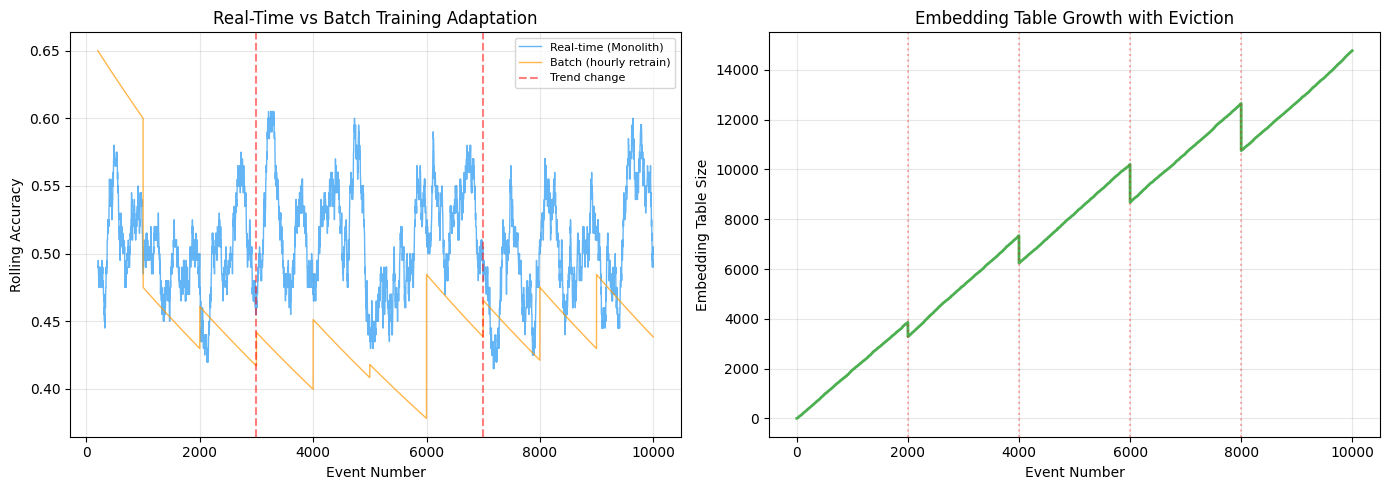

In [3]:
# Compare real-time vs batch training adaptation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Rolling accuracy over time (real-time training)
x = range(window, len(rt_results))
axes[0].plot(x, rolling_accuracy, linewidth=1, color='#2196F3', alpha=0.7, label='Real-time (Monolith)')

# Simulate batch training (retrained every 1000 events)
batch_accuracy = []
current_batch_acc = 0.65
for i in range(window, len(rt_results)):
    if i % 1000 == 0:  # Batch retrain
        current_batch_acc = rolling_accuracy[i - window] * 0.95  # Slightly worse due to delay
    else:
        # Accuracy degrades between retrains due to concept drift
        current_batch_acc *= 0.9999
    batch_accuracy.append(current_batch_acc)

axes[0].plot(x, batch_accuracy, linewidth=1, color='#FF9800', alpha=0.7, label='Batch (hourly retrain)')

# Mark trend changes
axes[0].axvline(x=3000, color='red', linestyle='--', alpha=0.5, label='Trend change')
axes[0].axvline(x=7000, color='red', linestyle='--', alpha=0.5)

axes[0].set_xlabel("Event Number")
axes[0].set_ylabel("Rolling Accuracy")
axes[0].set_title("Real-Time vs Batch Training Adaptation")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# Right: Embedding table growth and eviction
# Simulate table size over time with eviction
table_sizes = []
table_size = 0
eviction_events = []
for i in range(n_events):
    # New embeddings added
    table_size += np.random.poisson(2)
    # Eviction every 2000 events
    if i % 2000 == 0 and i > 0:
        evicted = int(table_size * 0.15)  # Evict 15%
        table_size -= evicted
        eviction_events.append(i)
    table_sizes.append(table_size)

axes[1].plot(range(n_events), table_sizes, linewidth=2, color='#4CAF50')
for ev in eviction_events:
    axes[1].axvline(x=ev, color='red', linestyle=':', alpha=0.3)
axes[1].set_xlabel("Event Number")
axes[1].set_ylabel("Embedding Table Size")
axes[1].set_title("Embedding Table Growth with Eviction")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Alibaba's Production Stack

Alibaba operates one of the world's largest e-commerce recommendation systems. Key components:

### COLD (Computing power cost-aware Online and Lightweight Deep pre-ranking)
A cost-efficient pre-ranking model that reduces candidates from 10K to 500 with minimal compute:
- Uses **SE blocks** (Squeeze-and-Excitation) for feature selection
- Runs on CPU for cost efficiency
- Typically 10x faster than the full ranking model

### SIM (Search-based Interest Model)
Handles **extremely long user behavior sequences** (up to 54,000 historical actions):
- **Two-stage approach**: First retrieval of relevant history via search, then attention
- General Search Unit (GSU): Fast retrieval of relevant history items
- Exact Search Unit (ESU): Attention over retrieved items

$$
\text{SIM}(u, i) = \text{ESU}(\text{GSU}(\mathbf{h}_u, i), i)
$$

### TDM (Tree-based Deep Model)
Novel retrieval approach using a **tree structure** over the item catalog:
- Items organized in a hierarchical tree
- Beam search from root to leaf for efficient retrieval
- $O(\log N)$ retrieval complexity vs $O(N)$ for brute force

> **⚠️ Common Pitfall:** SIM's two-stage search over long histories adds latency. Alibaba found that the GSU stage must be highly optimized (cached, pre-computed) to keep total latency under budget. The actual attention (ESU) is only applied to the top ~100 retrieved history items.

In [4]:
# Simulate SIM (Search-based Interest Model)

class SIMModel:
    """Simplified Search-based Interest Model.

    Reference: Pi et al., 'Search-based User Interest Modeling with Lifelong
    Sequential Behavior Data for Click-Through Rate Prediction' (2020, Alibaba)
    """

    def __init__(self, num_items: int, embedding_dim: int = 32):
        self.num_items = num_items
        self.embedding_dim = embedding_dim
        self.item_embeddings = np.random.randn(num_items, embedding_dim).astype(np.float32) * 0.01

    def general_search_unit(self, user_history: np.ndarray,
                            target_item: int, top_k: int = 100) -> np.ndarray:
        """GSU: Fast retrieval of relevant history items."""
        target_emb = self.item_embeddings[target_item % self.num_items]
        history_embs = self.item_embeddings[user_history % self.num_items]

        # Cosine similarity between target and each history item
        similarities = history_embs @ target_emb
        # Top-k indices
        top_k = min(top_k, len(user_history))
        top_indices = np.argsort(-similarities)[:top_k]
        return user_history[top_indices]

    def exact_search_unit(self, relevant_history: np.ndarray,
                          target_item: int) -> np.ndarray:
        """ESU: Attention over retrieved history items."""
        target_emb = self.item_embeddings[target_item % self.num_items]
        history_embs = self.item_embeddings[relevant_history % self.num_items]

        # Scaled dot-product attention
        scores = history_embs @ target_emb / np.sqrt(self.embedding_dim)
        attn_weights = np.exp(scores - scores.max())
        attn_weights = attn_weights / (attn_weights.sum() + 1e-8)

        # Weighted sum of history embeddings
        user_repr = attn_weights @ history_embs
        return user_repr

    def score(self, user_history: np.ndarray, target_item: int) -> Tuple[float, Dict]:
        """Full SIM scoring."""
        start = time.perf_counter()

        # Stage 1: GSU
        t1 = time.perf_counter()
        relevant = self.general_search_unit(user_history, target_item, top_k=100)
        gsu_time = (time.perf_counter() - t1) * 1000

        # Stage 2: ESU
        t2 = time.perf_counter()
        user_repr = self.exact_search_unit(relevant, target_item)
        esu_time = (time.perf_counter() - t2) * 1000

        # Final score
        target_emb = self.item_embeddings[target_item % self.num_items]
        score = float(np.dot(user_repr, target_emb))
        total_time = (time.perf_counter() - start) * 1000

        return score, {
            "gsu_time_ms": gsu_time,
            "esu_time_ms": esu_time,
            "total_time_ms": total_time,
            "history_length": len(user_history),
            "relevant_items": len(relevant),
        }


# Test SIM with different history lengths
np.random.seed(42)
sim = SIMModel(num_items=100000, embedding_dim=32)

history_lengths = [100, 500, 1000, 5000, 10000, 50000]
print(f"SIM Model Performance by History Length:")
print(f"{'History Length':>15} | {'GSU (ms)':>10} | {'ESU (ms)':>10} | {'Total (ms)':>10}")
print("-" * 55)

sim_latencies = []
for hist_len in history_lengths:
    history = np.random.randint(0, 100000, hist_len)
    target = np.random.randint(0, 100000)

    # Average over multiple runs
    times = []
    for _ in range(20):
        _, timing = sim.score(history, target)
        times.append(timing)

    avg_gsu = np.mean([t["gsu_time_ms"] for t in times])
    avg_esu = np.mean([t["esu_time_ms"] for t in times])
    avg_total = np.mean([t["total_time_ms"] for t in times])
    sim_latencies.append({"hist_len": hist_len, "gsu": avg_gsu, "esu": avg_esu, "total": avg_total})

    print(f"{hist_len:>15,} | {avg_gsu:>10.3f} | {avg_esu:>10.3f} | {avg_total:>10.3f}")

SIM Model Performance by History Length:
 History Length |   GSU (ms) |   ESU (ms) | Total (ms)
-------------------------------------------------------
            100 |      0.031 |      0.028 |      0.062
            500 |      0.055 |      0.031 |      0.088
          1,000 |      0.098 |      0.029 |      0.131
          5,000 |      0.836 |      0.061 |      0.903
         10,000 |      1.945 |      0.066 |      2.017


         50,000 |     11.090 |      0.086 |     11.185


## 3. Pinterest, LinkedIn, and Spotify

### Pinterest
- **PinSage** (Ying et al., 2018): GNN on the pin-board bipartite graph for item embeddings. Processes 3B nodes, 18B edges.
- **PinnerFormer** (Pancha et al., 2022): Transformer-based user representation that replaces real-time sequence models with a fixed-size representation updated daily.
- **Homefeed Ranking**: Multi-objective ranking with engagement, relevance, and quality signals.

### LinkedIn
- **GLMix** (Zhang et al., 2016): Generalized Linear Mixed models combining global, per-member, and per-item models.
- **Feed Ranking**: Multi-objective optimization for professional content (career growth, network building, content quality).
- **People You May Know**: Graph-based recommendation using professional network features.

### Spotify
- **Dual encoder** for podcast recommendation (learn user and podcast representations)
- **Sequential listening model**: RNN/Transformer over listening history
- **Explore-exploit**: Thompson Sampling for balancing known preferences vs discovery
- **Audio features**: Spectral analysis for music similarity (beyond collaborative filtering)

$$
\text{GLMix}: \hat{y}_{ui} = \underbrace{\mathbf{w}_g^T \mathbf{x}}_{\text{global}} + \underbrace{\mathbf{w}_u^T \mathbf{x}}_{\text{per-user}} + \underbrace{\mathbf{w}_i^T \mathbf{x}}_{\text{per-item}}
$$

> **🔑 Pro Tip:** PinnerFormer's key innovation is replacing real-time sequential models with a daily-updated user embedding. They found that a well-trained transformer on daily behavior captures 95% of the sequential signal at 10x lower serving cost.

In [5]:
# Implement GLMix (LinkedIn's approach)

class GLMix:
    """Generalized Linear Mixed Model.

    Reference: Zhang et al., 'GLMix: Generalized Linear Mixed Models
    For Large-Scale Response Prediction' (2016, LinkedIn, KDD)
    """

    def __init__(self, global_dim: int, user_dim: int, item_dim: int,
                 num_users: int, num_items: int):
        # Global model (shared across all users/items)
        self.w_global = np.random.randn(global_dim).astype(np.float32) * 0.01

        # Per-user models (personalized)
        self.w_users = np.random.randn(num_users, user_dim).astype(np.float32) * 0.001

        # Per-item models
        self.w_items = np.random.randn(num_items, item_dim).astype(np.float32) * 0.001

        self.global_dim = global_dim
        self.user_dim = user_dim
        self.item_dim = item_dim

    def predict(self, global_features: np.ndarray,
                user_features: np.ndarray,
                item_features: np.ndarray,
                user_ids: np.ndarray,
                item_ids: np.ndarray) -> np.ndarray:
        """Predict using all three model components."""
        batch_size = len(user_ids)

        # Global component
        global_score = global_features @ self.w_global

        # Per-user component
        user_scores = np.array([
            np.dot(user_features[i], self.w_users[uid])
            for i, uid in enumerate(user_ids)
        ])

        # Per-item component
        item_scores = np.array([
            np.dot(item_features[i], self.w_items[iid])
            for i, iid in enumerate(item_ids)
        ])

        # Combined score
        logits = global_score + user_scores + item_scores
        return 1.0 / (1.0 + np.exp(-np.clip(logits, -20, 20)))


# Test GLMix
np.random.seed(42)
glmix = GLMix(
    global_dim=50, user_dim=20, item_dim=20,
    num_users=10000, num_items=50000
)

batch_size = 256
global_features = np.random.randn(batch_size, 50).astype(np.float32)
user_features = np.random.randn(batch_size, 20).astype(np.float32)
item_features = np.random.randn(batch_size, 20).astype(np.float32)
user_ids = np.random.randint(0, 10000, batch_size)
item_ids = np.random.randint(0, 50000, batch_size)

predictions = glmix.predict(global_features, user_features, item_features,
                            user_ids, item_ids)

print(f"GLMix (LinkedIn):")
print(f"  Global model size: {glmix.w_global.size:,} params")
print(f"  Per-user models: {glmix.w_users.size:,} params total")
print(f"  Per-item models: {glmix.w_items.size:,} params total")
print(f"  Prediction range: [{predictions.min():.4f}, {predictions.max():.4f}]")

GLMix (LinkedIn):
  Global model size: 50 params
  Per-user models: 200,000 params total
  Per-item models: 1,000,000 params total
  Prediction range: [0.4594, 0.5368]


## 4. Common Patterns Across Companies

Despite different products and scales, all major recommendation systems share common patterns:

### Architecture Patterns
1. **Multi-stage funnel**: Retrieval (cheap, broad) → Pre-ranking → Ranking (expensive, precise) → Re-ranking
2. **Embedding-based retrieval**: All companies use learned embeddings for fast ANN retrieval
3. **Multi-task prediction**: Predict multiple objectives (click, like, share, purchase) simultaneously
4. **Feature stores**: Centralized feature platforms for feature sharing across models

### Infrastructure Patterns
1. **GPU inference**: All major companies have moved ranking to GPU
2. **Real-time features**: Streaming pipelines for fresh user signals
3. **A/B testing at scale**: Automated experimentation platforms
4. **Model versioning**: Multiple model versions in production simultaneously

### Unique Differentiators

| Company | Unique Strength | Key Innovation |
|---------|----------------|----------------|
| Meta | Scale (10T predictions/day) | DLRM, HSTU |
| ByteDance | Real-time adaptation | Monolith |
| Alibaba | Long user histories | SIM, TDM |
| Tencent | Multi-scenario | PLE |
| Pinterest | Graph learning | PinSage |
| LinkedIn | Mixed effects | GLMix |
| Spotify | Exploration | Thompson Sampling at scale |

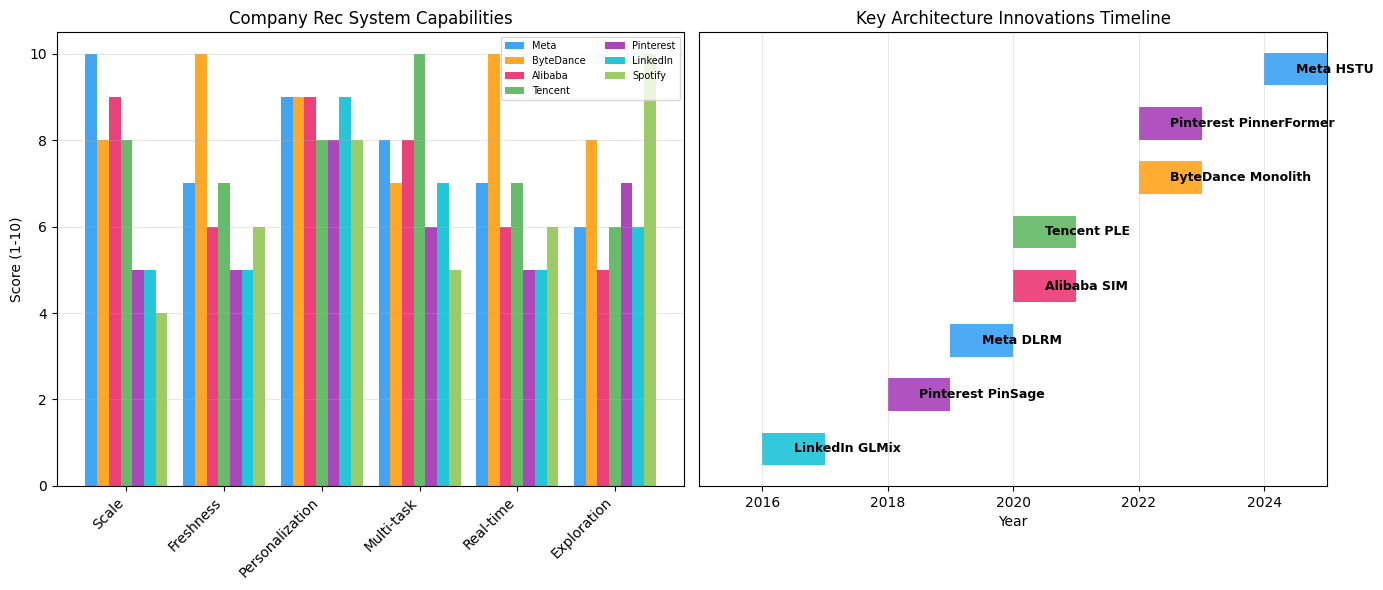

In [6]:
# Comprehensive comparison visualization

companies = [
    {"name": "Meta", "scale": 10, "freshness": 7, "personalization": 9,
     "multi_task": 8, "real_time": 7, "exploration": 6},
    {"name": "ByteDance", "scale": 8, "freshness": 10, "personalization": 9,
     "multi_task": 7, "real_time": 10, "exploration": 8},
    {"name": "Alibaba", "scale": 9, "freshness": 6, "personalization": 9,
     "multi_task": 8, "real_time": 6, "exploration": 5},
    {"name": "Tencent", "scale": 8, "freshness": 7, "personalization": 8,
     "multi_task": 10, "real_time": 7, "exploration": 6},
    {"name": "Pinterest", "scale": 5, "freshness": 5, "personalization": 8,
     "multi_task": 6, "real_time": 5, "exploration": 7},
    {"name": "LinkedIn", "scale": 5, "freshness": 5, "personalization": 9,
     "multi_task": 7, "real_time": 5, "exploration": 6},
    {"name": "Spotify", "scale": 4, "freshness": 6, "personalization": 8,
     "multi_task": 5, "real_time": 6, "exploration": 10},
]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Radar chart (approximated with bar chart)
dimensions = ["scale", "freshness", "personalization", "multi_task", "real_time", "exploration"]
dim_labels = ["Scale", "Freshness", "Personalization", "Multi-task", "Real-time", "Exploration"]

x = np.arange(len(dimensions))
width = 0.12
colors_company = ['#2196F3', '#FF9800', '#E91E63', '#4CAF50', '#9C27B0', '#00BCD4', '#8BC34A']

for i, company in enumerate(companies):
    values = [company[d] for d in dimensions]
    axes[0].bar(x + i * width, values, width, label=company["name"],
                color=colors_company[i], alpha=0.85)

axes[0].set_xticks(x + 3 * width)
axes[0].set_xticklabels(dim_labels, rotation=45, ha='right')
axes[0].set_ylabel("Score (1-10)")
axes[0].set_title("Company Rec System Capabilities")
axes[0].legend(fontsize=7, ncol=2)
axes[0].grid(axis='y', alpha=0.3)

# Right: Architecture timeline
timeline = [
    (2016, "LinkedIn GLMix", "#00BCD4"),
    (2018, "Pinterest PinSage", "#9C27B0"),
    (2019, "Meta DLRM", "#2196F3"),
    (2020, "Alibaba SIM", "#E91E63"),
    (2020, "Tencent PLE", "#4CAF50"),
    (2022, "ByteDance Monolith", "#FF9800"),
    (2022, "Pinterest PinnerFormer", "#9C27B0"),
    (2024, "Meta HSTU", "#2196F3"),
]

for i, (year, name, color) in enumerate(timeline):
    axes[1].barh(i, 1, left=year, height=0.6, color=color, alpha=0.8)
    axes[1].text(year + 0.5, i, name, va='center', fontsize=9, fontweight='bold')

axes[1].set_xlabel("Year")
axes[1].set_title("Key Architecture Innovations Timeline")
axes[1].set_yticks([])
axes[1].set_xlim(2015, 2025)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Lessons Learned

After analyzing recommendation systems across all these companies, several universal lessons emerge:

1. **Start simple, iterate fast**: Every company started with logistic regression. Complex architectures are layered on incrementally. Meta evolved from EdgeRank to DLRM over 8 years.

2. **Infrastructure > Model**: The companies with the best recommendations invest more in feature pipelines, experiment platforms, and monitoring than in model architecture. A simple model with great features beats a complex model with stale features.

3. **Multi-stage is universal**: Every company uses the retrieval → ranking → re-ranking funnel. The stages may differ in implementation, but the pattern is invariant.

4. **Freshness matters more than complexity**: ByteDance's Monolith (simple model, real-time) often beats more complex models with batch training on time-sensitive content.

5. **Multi-task is the norm**: No company optimizes a single metric. All use multi-objective optimization with carefully balanced task weights.

6. **Monitoring is the safety net**: Production issues are inevitable. The companies with the best monitoring (Meta, ByteDance) recover fastest from incidents.

In [7]:
# Decision framework: which architecture for your use case?

def recommend_architecture(use_case: Dict) -> List[str]:
    """Recommend architecture based on use case characteristics."""
    recommendations = []

    # Scale-based
    if use_case.get("daily_users", 0) > 100_000_000:
        recommendations.append("DLRM-style with model parallelism (Meta approach)")
    elif use_case.get("daily_users", 0) > 10_000_000:
        recommendations.append("Standard deep ranking model (single machine GPU)")
    else:
        recommendations.append("GLMix or simple deep model (LinkedIn approach)")

    # Content-type based
    content_type = use_case.get("content_type", "")
    if content_type == "short_video":
        recommendations.append("Monolith real-time training (ByteDance approach)")
    elif content_type == "ecommerce":
        recommendations.append("SIM for long user histories (Alibaba approach)")
    elif content_type == "social_feed":
        recommendations.append("Sequential model (HSTU-style)")
    elif content_type == "music":
        recommendations.append("Dual encoder + explore-exploit (Spotify approach)")

    # Multi-scenario
    if use_case.get("num_scenarios", 1) > 3:
        recommendations.append("PLE for multi-scenario (Tencent approach)")

    # Graph-heavy
    if use_case.get("has_social_graph", False):
        recommendations.append("PinSage-style GNN for item embeddings")

    return recommendations


# Test with different use cases
use_cases = [
    {"name": "Large social media", "daily_users": 500_000_000,
     "content_type": "social_feed", "num_scenarios": 5, "has_social_graph": True},
    {"name": "Short video app", "daily_users": 100_000_000,
     "content_type": "short_video", "num_scenarios": 2, "has_social_graph": False},
    {"name": "E-commerce", "daily_users": 50_000_000,
     "content_type": "ecommerce", "num_scenarios": 3, "has_social_graph": False},
    {"name": "Music streaming", "daily_users": 20_000_000,
     "content_type": "music", "num_scenarios": 2, "has_social_graph": False},
    {"name": "B2B SaaS", "daily_users": 500_000,
     "content_type": "professional", "num_scenarios": 1, "has_social_graph": True},
]

for uc in use_cases:
    print(f"\n{'='*60}")
    print(f"Use Case: {uc['name']}")
    print(f"{'='*60}")
    recs = recommend_architecture(uc)
    for i, rec in enumerate(recs, 1):
        print(f"  {i}. {rec}")


Use Case: Large social media
  1. DLRM-style with model parallelism (Meta approach)
  2. Sequential model (HSTU-style)
  3. PLE for multi-scenario (Tencent approach)
  4. PinSage-style GNN for item embeddings

Use Case: Short video app
  1. Standard deep ranking model (single machine GPU)
  2. Monolith real-time training (ByteDance approach)

Use Case: E-commerce
  1. Standard deep ranking model (single machine GPU)
  2. SIM for long user histories (Alibaba approach)

Use Case: Music streaming
  1. Standard deep ranking model (single machine GPU)
  2. Dual encoder + explore-exploit (Spotify approach)

Use Case: B2B SaaS
  1. GLMix or simple deep model (LinkedIn approach)
  2. PinSage-style GNN for item embeddings


## Exercises

### 🏋️ Exercise 1: Compare Architectures on Synthetic Data

Implement simplified versions of 3 different company architectures and compare them on a synthetic recommendation task.

In [8]:
# 🏋️ Exercise 1: Architecture comparison

# TODO: Implement simplified versions of:
# 1. DLRM-style (Meta): Embedding + dot-product interactions + MLP
# 2. Monolith-style (ByteDance): Online-updated embeddings + simple scoring
# 3. SIM-style (Alibaba): Search over long history + attention
#
# Create a synthetic dataset with:
# - 10,000 users, 5,000 items
# - User history lengths varying from 10 to 1000
# - Concept drift at t=5000
#
# Compare:
# - Hit rate @ 10 over time
# - Adaptation speed after concept drift
# - Inference latency

### 🏋️ Exercise 2: Design Your Own Production Stack

Given a specific product scenario, design a complete recommendation stack.

In [9]:
# 🏋️ Exercise 2: Design a production stack

# Scenario: You're building a news recommendation app with:
# - 10M daily users
# - 100K articles published per day
# - Users expect <200ms latency
# - Content freshness is critical (news articles have short lifespans)
# - Multi-task: click, read_complete, share, subscribe
#
# TODO: Design and implement (simplified):
# 1. Retrieval strategy (what combination?)
# 2. Ranking model (which architecture?)
# 3. Feature pipeline (batch vs real-time?)
# 4. Training strategy (batch vs online?)
# 5. Monitoring (what metrics to track?)
#
# Justify each choice by referencing patterns from real companies

### 🏋️ Exercise 3: Technology Radar Analysis

Analyze which technologies from these companies are most applicable to different stages of company growth.

In [10]:
# 🏋️ Exercise 3: Technology adoption roadmap

# TODO: Create a visualization showing:
# X-axis: Company stage (startup → growth → scale → hyperscale)
# Y-axis: Technologies to adopt at each stage
#
# Stage 1 (Startup, <1M users):
#   - What to implement first?
# Stage 2 (Growth, 1-10M users):
#   - What to add?
# Stage 3 (Scale, 10-100M users):
#   - What becomes essential?
# Stage 4 (Hyperscale, >100M users):
#   - What do you need at this point?
#
# Plot this as a technology adoption heatmap

## Summary

Key takeaways from this survey of production recommendation systems:

1. **ByteDance Monolith** shows that real-time training can be more important than model complexity for time-sensitive content
2. **Alibaba's SIM** demonstrates how to handle extremely long user histories (54K+ items) efficiently with two-stage search
3. **Pinterest PinSage** proves that graph neural networks can work at billion-node scale for item representation
4. **LinkedIn GLMix** shows that personalized models (per-user and per-item effects) can outperform one-size-fits-all deep models
5. **Spotify** demonstrates the importance of exploration and serendipity in recommendation
6. **Universal patterns**: multi-stage funnel, embedding retrieval, multi-task prediction, feature stores, A/B testing
7. **The best architecture depends on your specific constraints**: content type, freshness requirements, scale, and available infrastructure

### References

- Zhao et al., "Monolith: Real Time Recommendation System With Collisionless Embedding Table" (2022, ByteDance, ICLR)
- Pi et al., "Search-based User Interest Modeling with Lifelong Sequential Behavior Data for CTR Prediction" (2020, Alibaba, CIKM)
- Zhu et al., "Joint Optimization of Tree-based Index and Deep Model for Recommender Systems" (2019, Alibaba, NeurIPS)
- Ying et al., "Graph Convolutional Neural Networks for Web-Scale Recommender Systems" (2018, Pinterest, KDD)
- Pancha et al., "PinnerFormer: Sequence Modeling for User Representation at Pinterest" (2022, Pinterest, KDD)
- Zhang et al., "GLMix: Generalized Linear Mixed Models For Large-Scale Response Prediction" (2016, LinkedIn, KDD)
- Briand et al., "A Semi-Personalized System for User Cold Start Recommendation on Music Streaming Apps" (2021, Spotify)